### TerraNova FEMA recovery Cost forcating model & Evaluation

In [62]:
# Purpose:

# The purpose of this modelling stage is to train machine learning models that can predict the expected FEMA disaster recovery cost.

# Because disaster cost is usually highly skewed, we use a log-transformed target:

# log_total_obligated`

# This helps the model learn better patterns from very large and very small disaster costs.

# Models Used:

# Linear Regression -  Simple, fast, interpretable baseline model.

#  Random Forest Regressor - Handles non-linear relationships and feature interactions.

# XGBoost Regressor - Advanced boosting model, often strong for tabular data.

In [63]:

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")

os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(
    os.path.join(DATA_PROCESSED, "features_fema.csv")
)

print(df.shape)
df.head()

(5184, 22)


,disasternumber,state,declarationtype,incidenttype,fydeclared,designatedarea,declarationrequestnumber,disaster_duration_days,declaration_delay_days,declaration_year,...,declaration_season,fy_declaration_count,state_declaration_count,incident_frequency,state_incident_count,state_year_count,avg_duration_days,avg_delay_days,totalobligated,log_totalobligated
0,3610,PR,EM,Severe Storm,2024,Adjuntas (Municipio),24124,3.0,0,2024,...,Summer,2147,2116,19308,380,91,3.0,0.0,0.00,0.000000
1,5529,OR,FM,Fire,2024,Washington (County),24122,0.0,1,2024,...,Summer,2147,646,3876,180,33,0.0,1.0,0.00,0.000000
2,5528,OR,FM,Fire,2024,Jefferson (County),24116,0.0,2,2024,...,Summer,2147,646,3876,180,33,0.0,2.0,0.00,0.000000
3,5527,OR,FM,Fire,2024,Deschutes (County),24111,0.0,0,2024,...,Summer,2147,646,3876,180,33,0.0,0.0,0.00,0.000000
4,4312,CA,DR,Severe Storm,2017,Resighini Rancheria (Indian Reservation),17035,3.0,83,2017,...,Spring,1835,1689,19308,384,115,3.0,83.0,269934.77,12.505939


### STEP 2 - Prepare Target

- The target column is: 'total_obligated`

- This represents FEMA obligated recovery cost.

- Because cost data is highly skewed, we created:

`log_total_obligated`


### STEP 3 - Features and Train/Test Split



In [64]:
# step 3a:

FEATURE_COLS = [
    "fydeclared",
    "declaration_delay_days",
    "avg_delay_days",
    "declaration_year",
    "declaration_month",
    "declaration_quarter",
    "declaration_season",
    "state",
    "declarationtype",
    "incidenttype",
    "designatedarea"
]

print(f"{len(FEATURE_COLS)} features selected")
print(FEATURE_COLS)

11 features selected
['fydeclared', 'declaration_delay_days', 'avg_delay_days', 'declaration_year', 'declaration_month', 'declaration_quarter', 'declaration_season', 'state', 'declarationtype', 'incidenttype', 'designatedarea']


In [65]:
# step 3b  -  Prepare X and y

X = df[FEATURE_COLS]
y = df["log_totalobligated"]

print(X.shape)
print(y.shape)

(5184, 11)
(5184,)


In [66]:
# step 3c split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {len(X_train):,}")
print(f"Test : {len(X_test):,}")

Train: 4,147
Test : 1,037



### STEP 4 - Encoding and Scaling Pipeline

In [67]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical features:", len(categorical_features))
print(categorical_features)

Categorical features: 5
['declaration_season', 'state', 'declarationtype', 'incidenttype', 'designatedarea']


In [68]:

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print(categorical_features)


numeric_pipeline = Pipeline(
    steps=[
        
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

Numeric features: 6
Categorical features: 5
['declaration_season', 'state', 'declarationtype', 'incidenttype', 'designatedarea']


### STEP 5 - Define Models

We train three regression models:

1. Linear Regression  
2. Random Forest Regressor  
3. XGBoost Regresso

In [69]:
# baseline model
lr = LinearRegression()

# advance  model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)


xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


###  STEP 6 - Training Process

In [70]:

MODELS = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = {}
trained_models = {}

for name, model in MODELS.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    preds_log = pipeline.predict(X_test)

    mae_log = mean_absolute_error(y_test, preds_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, preds_log))
    r2 = r2_score(y_test, preds_log)

    y_test_original = np.expm1(y_test)
    preds_original = np.expm1(preds_log)

    mae_original = mean_absolute_error(y_test_original, preds_original)
    rmse_original = np.sqrt(mean_squared_error(y_test_original, preds_original))

    results[name] = {
        "MAE_log": mae_log,
        "RMSE_log": rmse_log,
        "R2": r2,
        "MAE_original": mae_original,
        "RMSE_original": rmse_original
    }

    trained_models[name] = pipeline

    print(
        f"{name:25s} | "
        f"RMSE log: {rmse_log:.4f} | "
        f"R2: {r2:.4f} | "
        f"MAE original: {mae_original:,.2f}"
    )

Linear Regression         | RMSE log: 5.3626 | R2: 0.5063 | MAE original: 16,259,186,273.88
Random Forest             | RMSE log: 3.0680 | R2: 0.8384 | MAE original: 61,644,953.66
XGBoost                   | RMSE log: 3.0153 | R2: 0.8439 | MAE original: 69,907,555.00


 STEP 7 - Compare Models


- MAE = average prediction error
- RMSE = punishes large errors more strongly
- R2 = how much variation in disaster cost the model explains

The best model should have:

- lower MAE
- lower RMSE
- higher R2

### STEP 8 - feature importance

In [71]:
rf_pipeline = trained_models["Random Forest"]

importances = rf_pipeline.named_steps["model"].feature_importances_

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(len(feature_names))
print(len(importances))

1143
1143


In [72]:
fi = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

fi.head(20)

,feature,importance
3,num__declaration_year,0.282193
1,num__declaration_delay_days,0.234292
2,num__avg_delay_days,0.195264
69,cat__declarationtype_DR,0.117205
0,num__fydeclared,0.047884
83,cat__incidenttype_Hurricane,0.018855
70,cat__declarationtype_EM,0.015508
71,cat__declarationtype_FM,0.012131
72,cat__incidenttype_Biological,0.004123
87,cat__incidenttype_Severe Storm,0.003091


In [73]:

results_df = (
    pd.DataFrame(results)
    .T
    .sort_values("RMSE_log")
)

results_df

,MAE_log,RMSE_log,R2,MAE_original,RMSE_original
XGBoost,1.289780,3.015306,0.843905,6.990755e+07,8.978934e+08
Random Forest,1.181760,3.068032,0.838398,6.164495e+07,8.464262e+08
Linear Regression,4.026705,5.362558,0.506291,1.625919e+10,5.183695e+11


### STEP 9 - Predicted vs Actual Plot

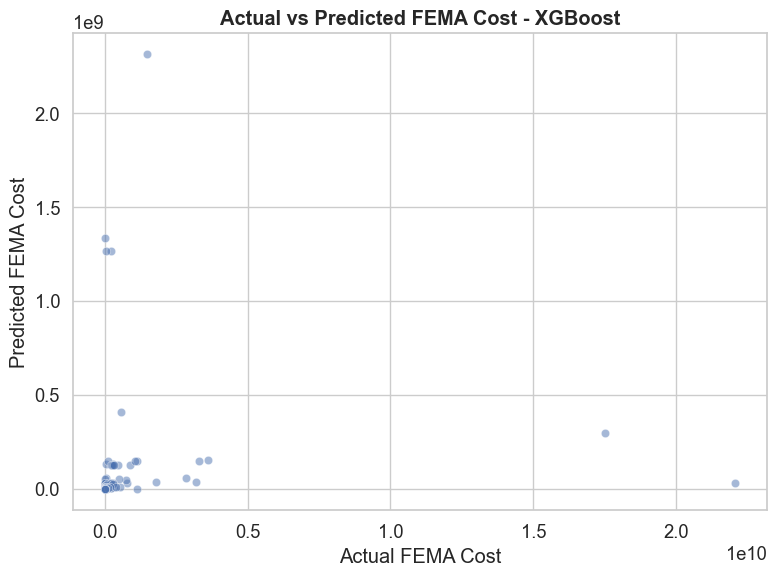

Best model: XGBoost


In [74]:

best_name = results_df.index[0]
best_model = trained_models[best_name]

preds_log = best_model.predict(X_test)

actual = np.expm1(y_test)
predicted = np.expm1(preds_log)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=actual,
    y=predicted,
    alpha=0.5
)

plt.xlabel("Actual FEMA Cost")
plt.ylabel("Predicted FEMA Cost")
plt.title(f"Actual vs Predicted FEMA Cost - {best_name}", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Best model: {best_name}")

### STEP 10 - Save Best Model

In [75]:

joblib.dump(
    best_model,
    os.path.join(MODEL_DIR, "fema_cost_model.pkl")
)

print(f"Best model saved: {best_name}")
print("Saved to:", os.path.join(MODEL_DIR, "fema_cost_model.pkl"))

Best model saved: XGBoost
Saved to: ..\models\fema_cost_model.pkl
